In [1]:
# IRIS data
import pandas as pd
iris_df = pd.read_csv('../data/iris.csv')

iris_df.describe()
iris_df.info()
iris_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load the Iris Dataset
X = iris_df.drop('Species', axis = 1)  # Features: sepal/petal length and width
# target variable label encoding
y = iris_df['Species']  # Target: species (0, 1, or 2)
le = LabelEncoder()
y = le.fit_transform(y)

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Essential for distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# n_neighbors=3 means we look at the 3 closest points
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make Predictions
predictions = knn.predict(X_test)

# Evaluate Performance
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, predictions))


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



<Figure size 800x600 with 0 Axes>

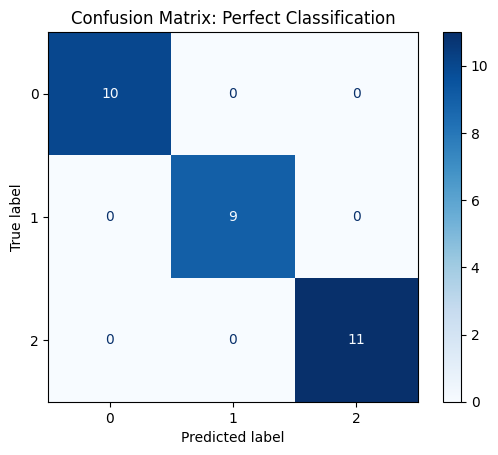

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# visualization of confusion matrix
plt.figure(figsize=(8, 6))
# Using ConfusionMatrixDisplay for a professional look
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Perfect Classification')
plt.show()

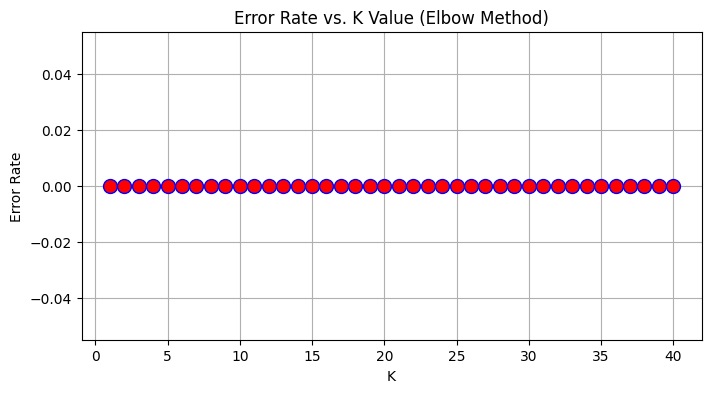

In [16]:
# plot elbow curve
# Calculate error rates for a range of K values
error_rate = []
for i in range(1, 41):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    # Average of where predicted label does not match actual label
    error_rate.append(np.mean(pred_i != y_test))

# Plot the Error Rate vs K Value
plt.figure(figsize=(8, 4))
plt.plot(range(1, 41), error_rate, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Elbow Method)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

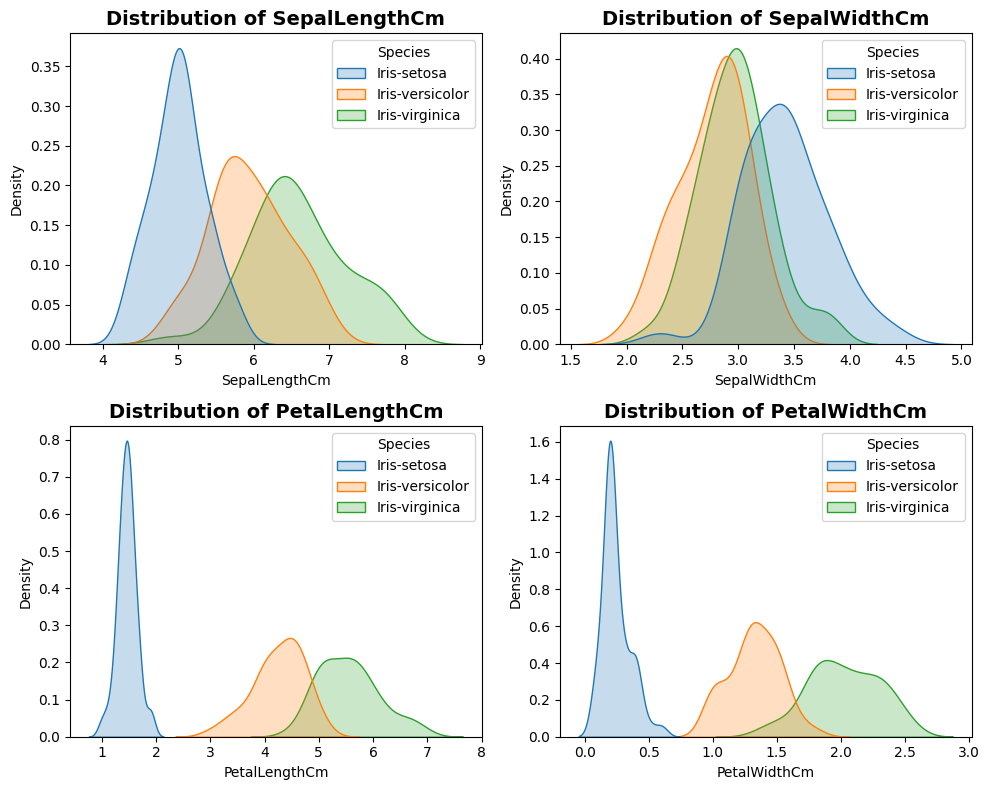

In [20]:
import seaborn as sns

# KDE plots to check how IRIS data is perfect meaning they are not overlapping
cols_to_plot = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

# draw each plot
for i, col in enumerate(cols_to_plot):
    sns.kdeplot(data=iris_df, x=col, ax=axes[i], hue='Species', fill=True)
    
    # Customizing each subplot
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')

plt.tight_layout() # Fixes overlapping titles/labels
plt.show()

In [23]:
# Pima Indians Diabetes data
import pandas as pd
Pima_Diabetes_df = pd.read_csv('../data/Pima Indians Diabetes.csv')

Pima_Diabetes_df.describe()
Pima_Diabetes_df.info()
Pima_Diabetes_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Confusion Matrix:
 [[36 14]
 [11 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.74        50
           1       0.53      0.59      0.56        27

    accuracy                           0.68        77
   macro avg       0.65      0.66      0.65        77
weighted avg       0.68      0.68      0.68        77



<Figure size 800x600 with 0 Axes>

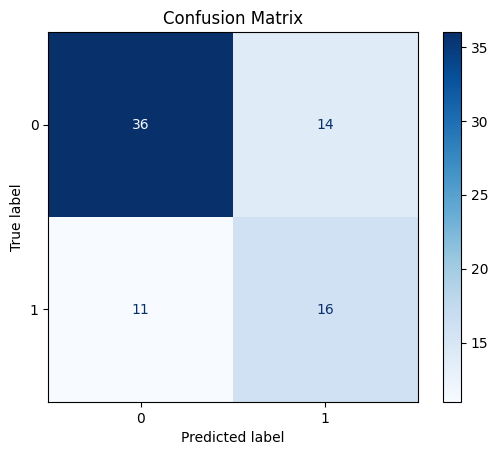

In [25]:
# Load the Dataset
X = Pima_Diabetes_df.drop('Outcome', axis = 1)
# target variable label encoding
y = Pima_Diabetes_df['Outcome']
le = LabelEncoder()
y = le.fit_transform(y)

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Feature Scaling (Essential for distance-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# n_neighbors=3 means we look at the 3 closest points
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make Predictions
predictions = knn.predict(X_test)

# Evaluate Performance
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, predictions))

# visualization of confusion matrix
plt.figure(figsize=(8, 6))
# Using ConfusionMatrixDisplay for a professional look
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix')
plt.show()

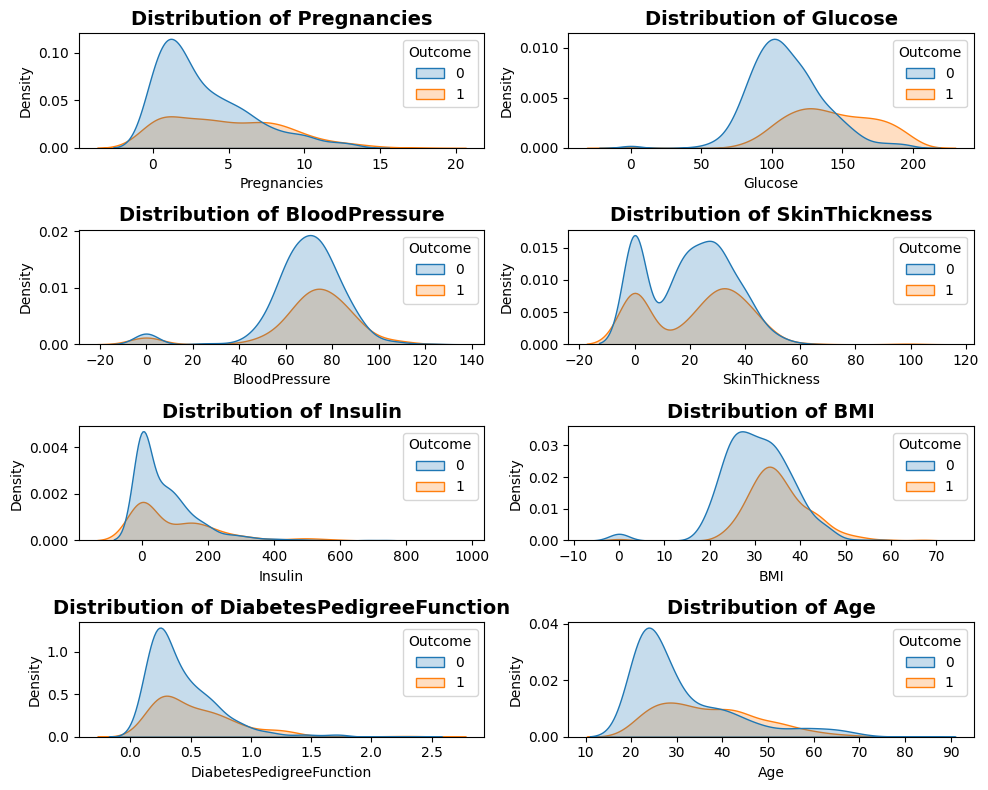

In [26]:
# KDE plots to check how data is overlapping
cols_to_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 8))
axes = axes.flatten()

# draw each plot
for i, col in enumerate(cols_to_plot):
    sns.kdeplot(data=Pima_Diabetes_df, x=col, ax=axes[i], hue='Outcome', fill=True)
    
    # Customizing each subplot
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')

plt.tight_layout() # Fixes overlapping titles/labels
plt.show()

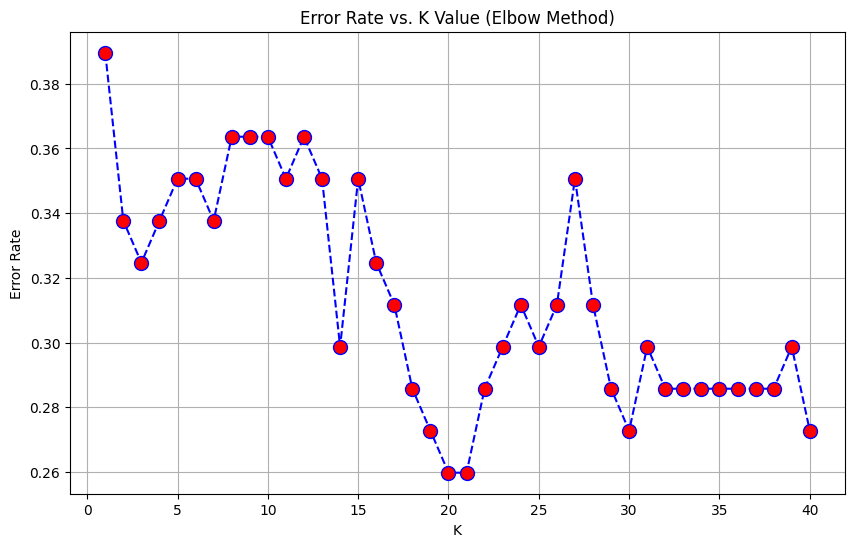

In [27]:
# plot elbow curve
# Calculate error rates for a range of K values
error_rate = []
for i in range(1, 41):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    # Average of where predicted label does not match actual label
    error_rate.append(np.mean(pred_i != y_test))

# Plot the Error Rate vs K Value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 41), error_rate, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (Elbow Method)')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

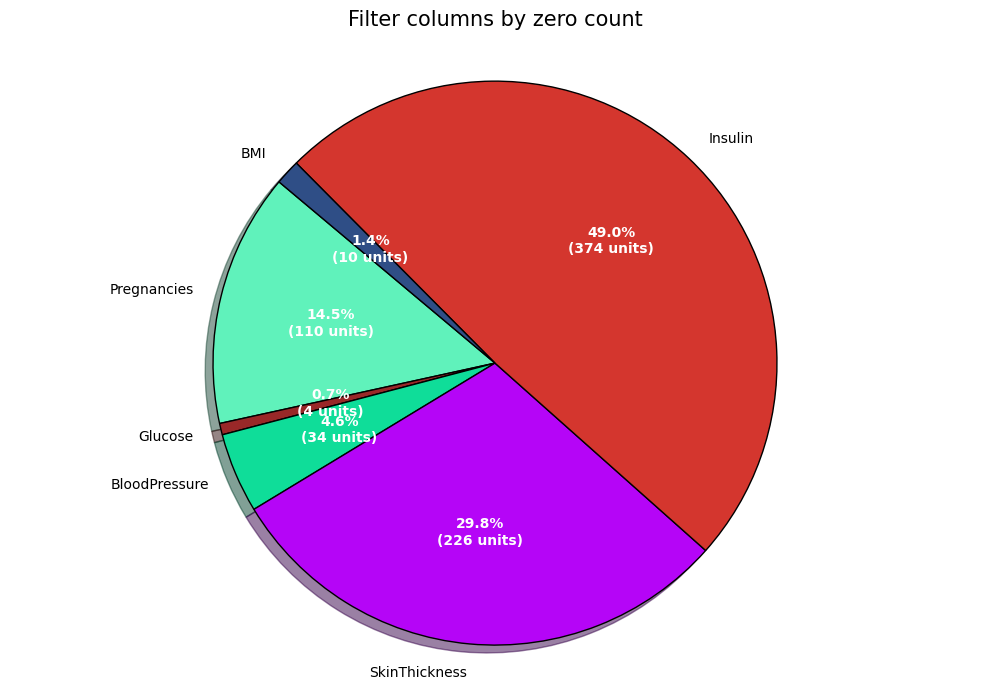

In [34]:
# filter columns by 0 counts
label_counts = {}
columns = Pima_Diabetes_df.columns.drop('Outcome')
for col in columns:
    data = Pima_Diabetes_df[col]
    count = data[data == 0].count()
    if count > 0:
        label_counts[col] = count
        
labels = list(label_counts.keys())
counts = list(label_counts.values())

# Generate Random Color Combinations
# We generate a unique RGB tuple for each label
np.random.seed(42) # Optional: Remove this for "true" randomness every time
random_colors = np.random.rand(len(labels), 3) 

# Create the Pie Chart
plt.figure(figsize=(10, 7))

# Parameters explained:
# x: The counts/values
# labels: The names of the categories
# autopct: String format to show both the percentage and the raw count
# colors: Our generated random RGB array
# startangle: Rotates the chart for better alignment
patches, texts, autotexts = plt.pie(
    counts, 
    labels=labels, 
    autopct=lambda p: '{:.1f}%\n({:d} units)'.format(p, int(p/100.*sum(counts))),
    colors=random_colors,
    startangle=140,
    shadow=True,
    wedgeprops={'edgecolor': 'black'} # Adds a border to separate random colors
)

# Styling the text for readability
plt.setp(autotexts, size=10, weight="bold", color="white")
plt.title("Filter columns by zero count", fontsize=15, pad=20)

plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

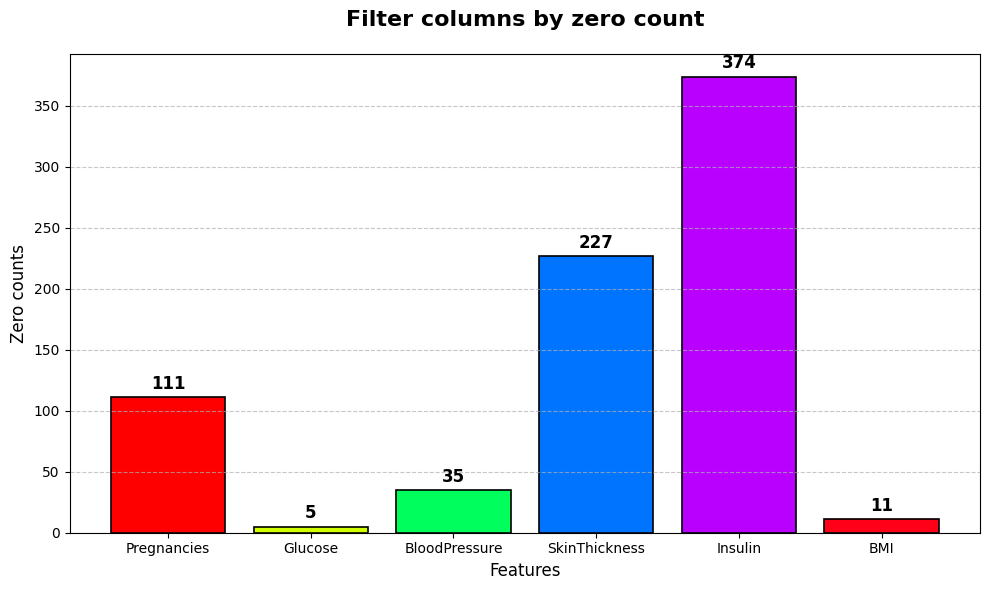

In [35]:
# BAR charts
# Extract keys (labels) and values (counts) for plotting
labels = list(label_counts.keys())
counts = list(label_counts.values())

# Generate Random Colors for each bar
# We use a colormap 'hsv' to get a diverse range of colors automatically
colors = plt.cm.hsv(np.linspace(0, 1, len(labels)))

# Create the Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.2)

# Add Data Labels (The exact count on top of each bar)
# This is a professional touch so you don't have to "guess" the Y-axis value
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Final Styling
ax.set_title('Filter columns by zero count', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Zero counts', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7) # Grid only on Y-axis for scale

plt.tight_layout()
plt.show()
